# Partition et Entraînement

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import featuretools as ft
import os

current_directory = os.getcwd()
repertory_path = os.path.abspath(os.path.join(current_directory, "..", ".."))

In [2]:
data = pd.read_csv(current_directory + "/Data_Preparation_Output.csv")
data.head()

,Bug,AvgCyclomatic,AvgCyclomaticModified,AvgCyclomaticStrict,AvgEssential,AvgCountLine,AvgCountLineBlank,AvgCountLineCode,AvgCountLineComment,CountDeclClass,...,CountStmtExe,MaxCyclomatic,MaxCyclomaticModified,MaxCyclomaticStrict,RatioCommentToCode,SumCyclomatic,SumCyclomaticModified,SumCyclomaticStrict,SumEssential,MaxNesting
0,0,2.0,2.0,2.0,1.0,11.0,0.0,11.0,0.0,9.0,...,143.0,8.0,8.0,8.0,0.11,58.0,58.0,61.0,34.0,4.0
1,1,4.0,2.0,4.0,1.0,14.0,0.0,13.0,1.0,1.0,...,112.0,42.0,9.0,42.0,0.10,66.0,30.0,66.0,22.0,2.0
2,0,4.0,4.0,4.0,1.0,18.0,1.0,15.0,2.0,7.0,...,303.0,15.0,15.0,16.0,0.14,124.0,124.0,133.0,40.0,5.0
3,0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,0.0,1.0,...,5.0,1.0,1.0,1.0,0.95,5.0,5.0,5.0,5.0,0.0
4,1,2.0,2.0,3.0,1.0,10.0,1.0,8.0,1.0,1.0,...,129.0,11.0,11.0,15.0,0.24,58.0,58.0,71.0,32.0,4.0


## 1. Analyse et Amélioration des Données

### 1.1 Vérifier la Qualité des Données

Des valeurs extrêmes peuvent biaiser les modèles tandis que des étiquettes incorrectes peuvent nuire à l'apprentissage du modèle.



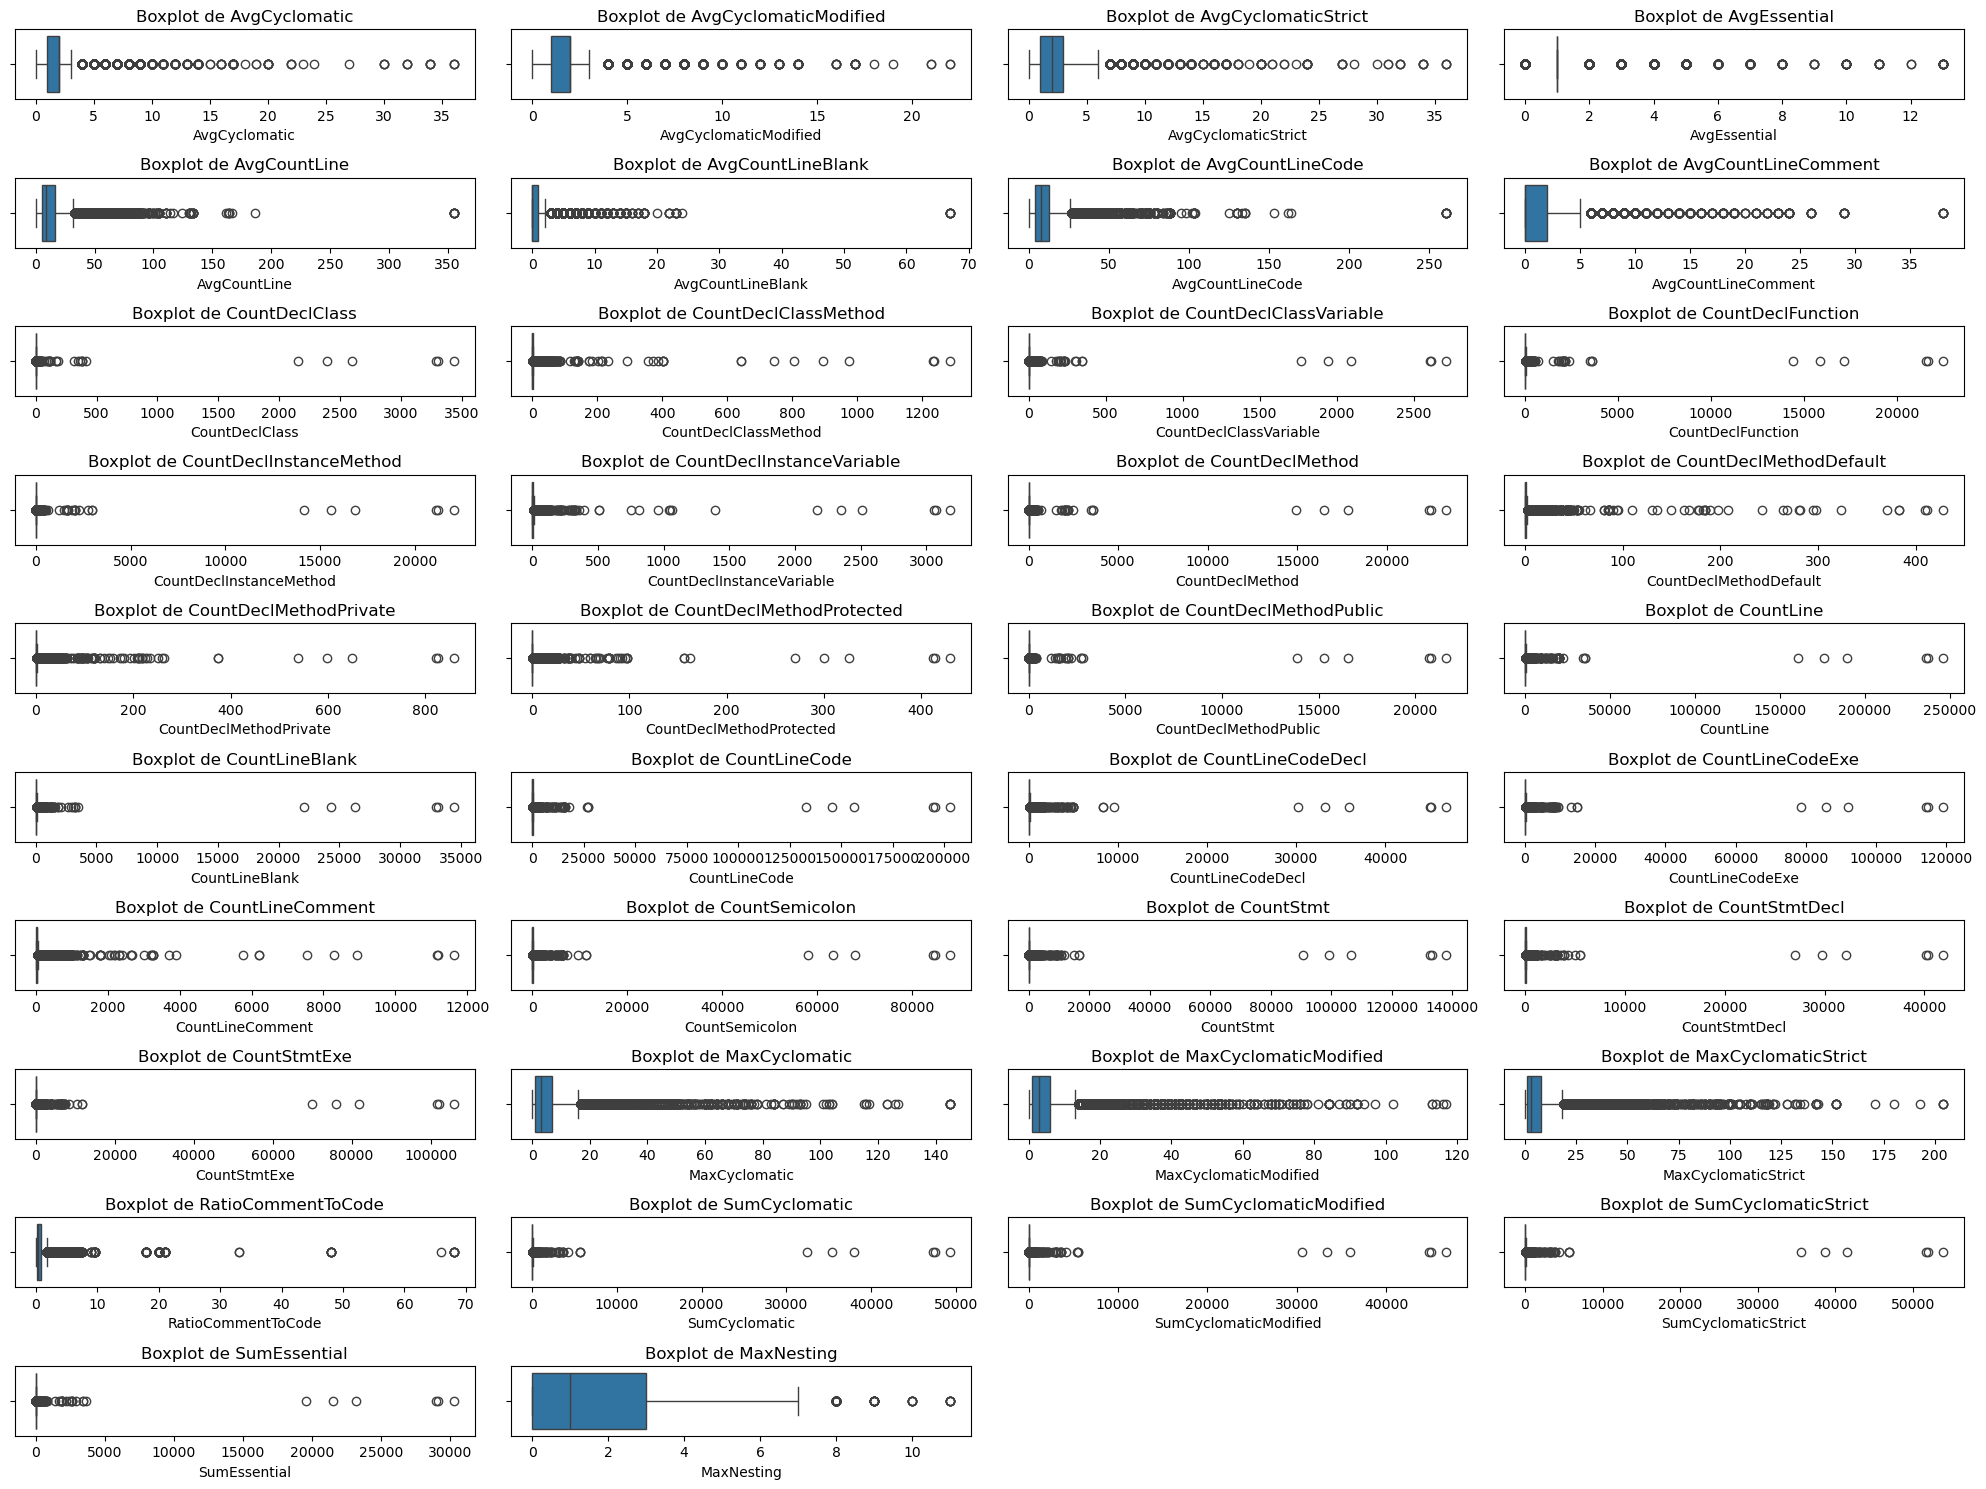

In [3]:
numeric_features = data.select_dtypes(include=['float64']).columns.tolist()
plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(10, 4, i)
    sns.boxplot(x=data[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

On peut voir sur les box plots ci-haut qu'une certaine partie de nos données sont aberrantes. On peut les nettoyer

In [4]:
def remove_outliers(df, numeric_cols, std_threshold=3):
    df_clean = data.copy()
    
    for col in numeric_cols:
        mean = df_clean[col].mean()
        std = df_clean[col].std()
        df_clean = df_clean[abs(df_clean[col] - mean) <= std_threshold * std]
    
    return df_clean

numeric_columns = data.select_dtypes(include=['float64']).columns.tolist()

data_clean = remove_outliers(data, numeric_columns)

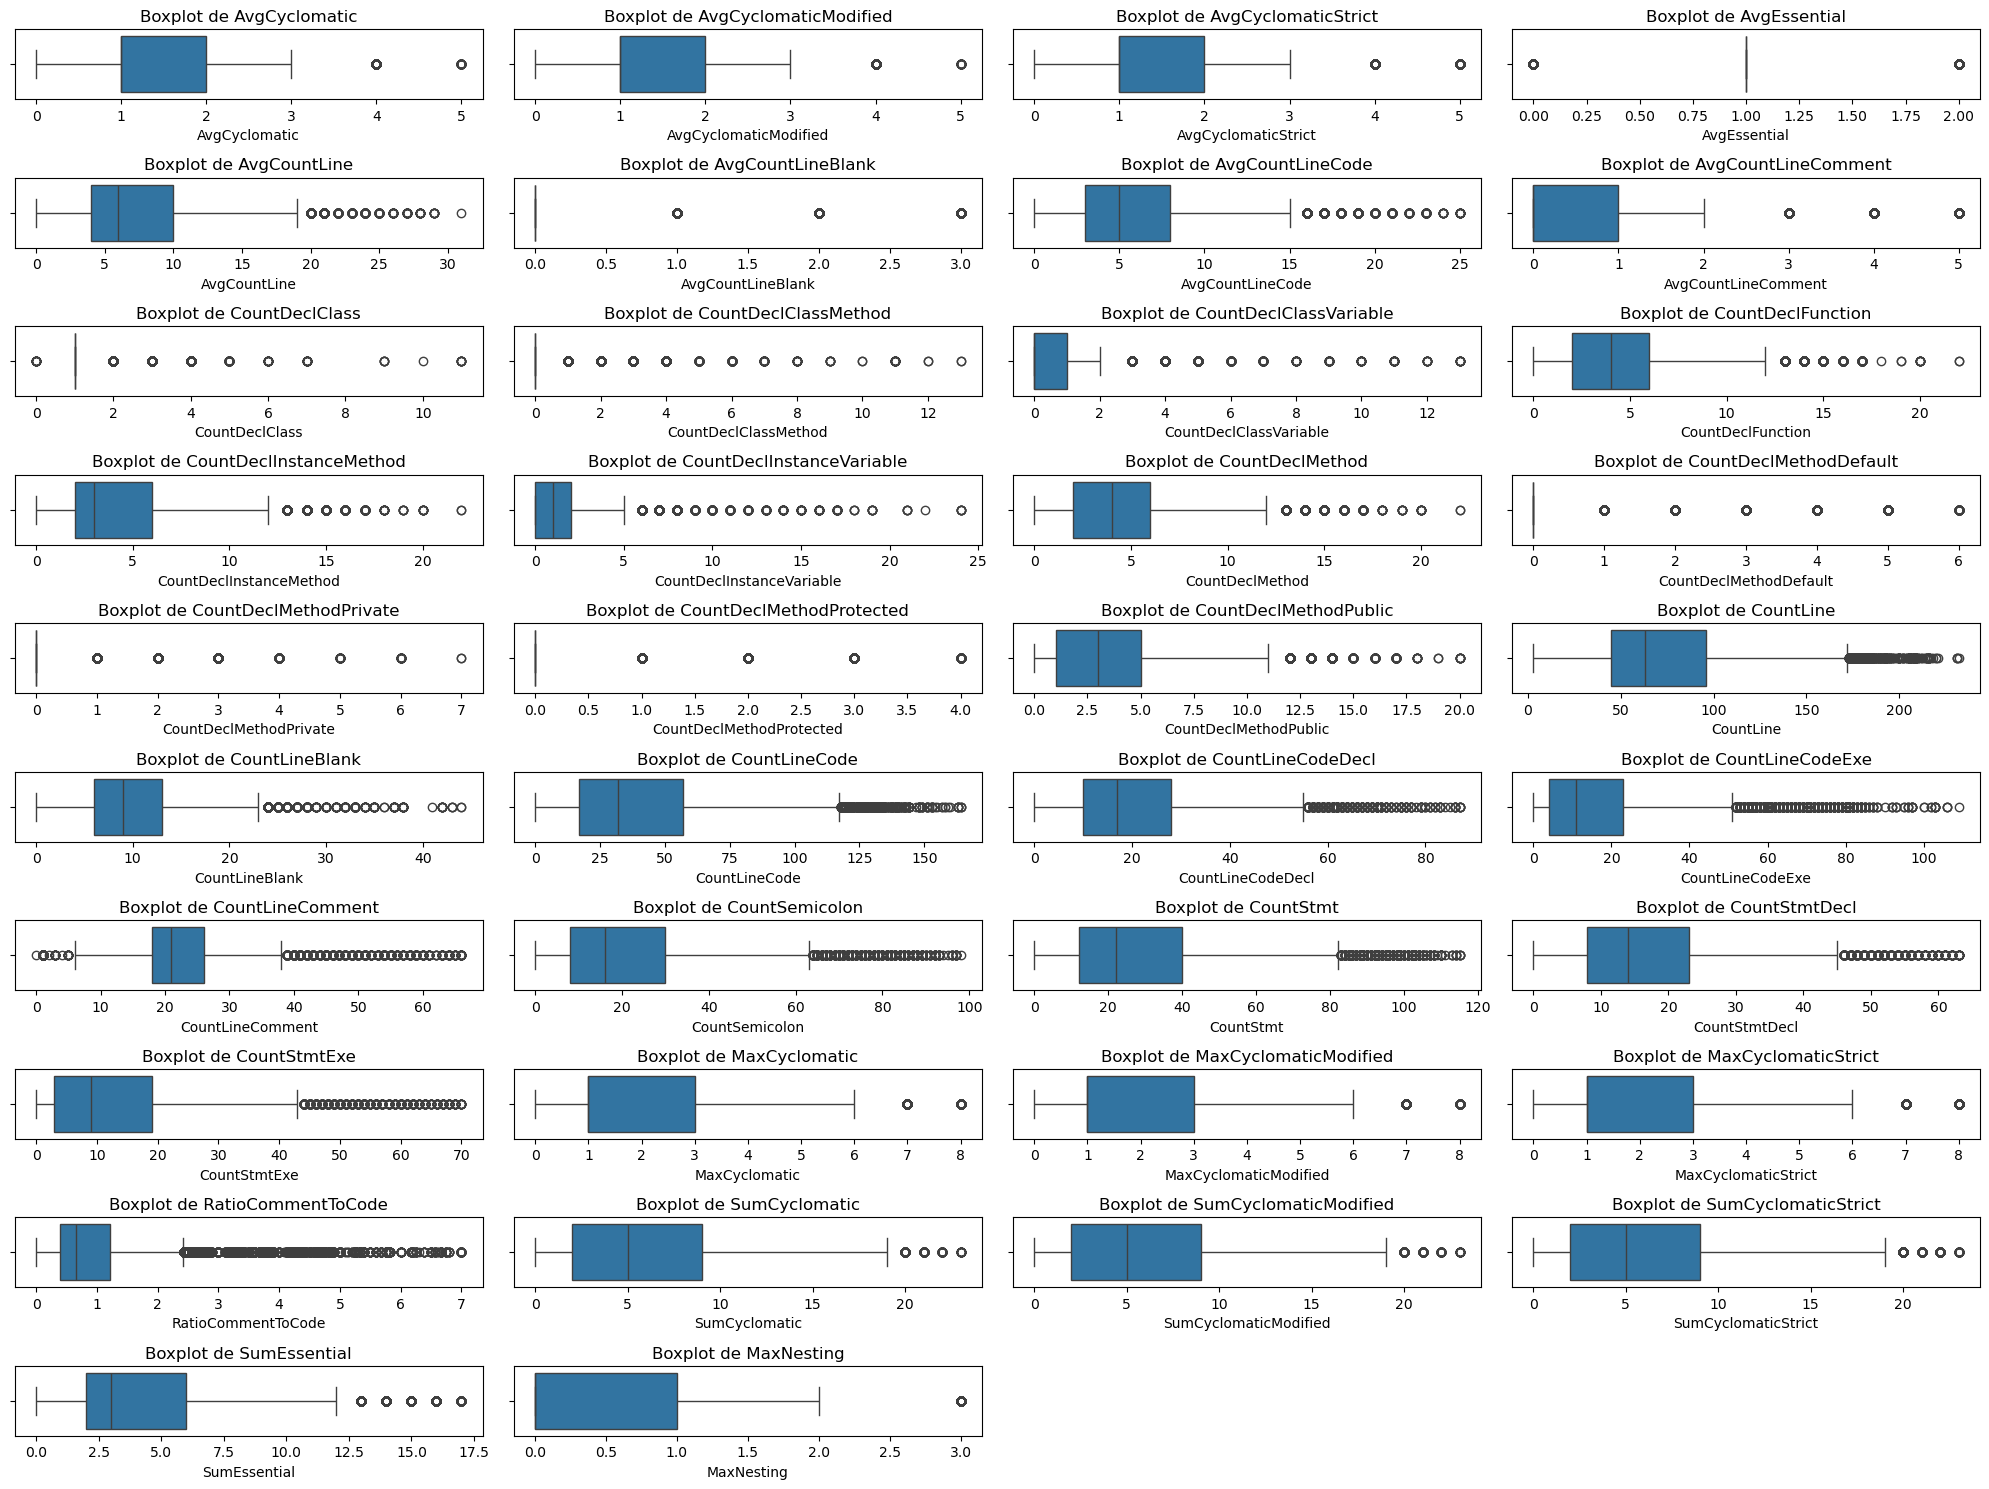

In [5]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(10, 4, i)
    sns.boxplot(x=data_clean[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

In [6]:
x = data_clean.drop('Bug', axis=1)
y = data_clean['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


### 1.2 Feature Engineering

On veut ici créer de nouvelles Features (ex: des ratios ou des interactions entre les features existantes) ou même transformer certaines Features (ex: normalisation ou standardisation des variables pour améliorer la convergence des algorithmes.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
import pandas as pd

Bug = data_clean.iloc[:, 0]          # Target variable (first column)
features = data_clean.iloc[:, 1:]    # Remaining 38 columns

scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)

scaled_features = scaler.fit_transform(features)
poly_features = poly.fit_transform(scaled_features)

poly_feature_names = poly.get_feature_names_out(features.columns)

data_transformed = pd.DataFrame(poly_features, columns=poly_feature_names)

data_transformed.insert(0, 'Bug', Bug.values)

print(data_transformed.columns)

Index(['Bug', 'AvgCyclomatic', 'AvgCyclomaticModified', 'AvgCyclomaticStrict',
       'AvgEssential', 'AvgCountLine', 'AvgCountLineBlank', 'AvgCountLineCode',
       'AvgCountLineComment', 'CountDeclClass',
       ...
       'SumCyclomaticModified^2', 'SumCyclomaticModified SumCyclomaticStrict',
       'SumCyclomaticModified SumEssential',
       'SumCyclomaticModified MaxNesting', 'SumCyclomaticStrict^2',
       'SumCyclomaticStrict SumEssential', 'SumCyclomaticStrict MaxNesting',
       'SumEssential^2', 'SumEssential MaxNesting', 'MaxNesting^2'],
      dtype='object', length=780)


In [8]:
x = data_transformed.drop('Bug', axis=1)
y = data_transformed['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


## 2. Partion des Données

In [9]:
x = data_transformed.drop('Bug', axis=1)
y = data_transformed['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


Il y a un déséquilibre, on doit donc remédier à ceci: 

Distribution des classes avant SMOTE :
Counter({0: 18930, 1: 2973})


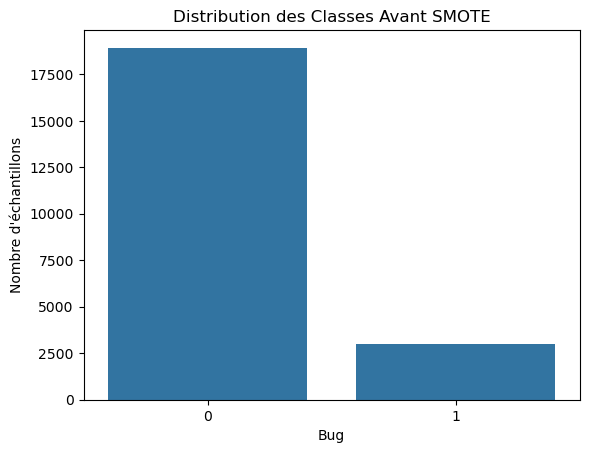

In [10]:
print('Distribution des classes avant SMOTE :')
print(Counter(y))

sns.countplot(x=y)
plt.title('Distribution des Classes Avant SMOTE')
plt.xlabel('Bug')
plt.ylabel('Nombre d\'échantillons')
plt.show()


In [11]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x, y)

print('Distribution des classes après SMOTE :')
print(Counter(y_train_res))

Distribution des classes après SMOTE :
Counter({0: 18930, 1: 18930})


## Entraînement

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,          # 20% pour le test
    random_state=42,        # Pour la reproductibilité
    stratify=y              # Maintenir la distribution des classes
)

On utilise SMOTE sur l'ensemble d'entraînement

On commence par séparer les données d'entraînement (train) des données de vérifications(test)

In [13]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [14]:
from sklearn.feature_selection import RFECV, VarianceThreshold

# Step 1: Pre-Select Features with Variance Threshold
variance_threshold = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed

# Step 2: Initialize Logistic Regression with an Efficient Solver
log_reg = LogisticRegression(
    solver='saga',         # Suitable for large datasets
    penalty='l1',          # Enables feature selection
    max_iter=10000,         # Increase if convergence warnings occur
    n_jobs=-1,             # Utilize all CPU cores
    random_state=42        # For reproducibility
)

# Step 3: Define Cross-Validation Strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced from default 5

# Step 4: Initialize RFECV with Optimized Parameters
rfecv_log_reg = RFECV(
    estimator=log_reg,
    step=0.2,               # Remove 20% of features each iteration
    cv=cv,
    scoring='roc_auc',
    verbose=0,              # Reduced verbosity
    n_jobs=-1,
    min_features_to_select=10  # Set based on domain knowledge
)

# Step 5: Create a Pipeline for Streamlined Processing
rfecv_log_reg_pipeline = Pipeline([
    ('variance_threshold', variance_threshold),
    ('scaler', StandardScaler()),  # Optional: Scaling can improve performance
    ('rfecv', rfecv_log_reg)
])

# Step 6: Fit the Pipeline to the Training Data
rfecv_log_reg_pipeline.fit(x_train_res, y_train_res)

# Step 7: Make Predictions on the Test Set
y_pred_log_reg = rfecv_log_reg_pipeline.predict(x_test)
y_pred_proba_log_reg = rfecv_log_reg_pipeline.predict_proba(x_test)[:, 1]

In [15]:
from sklearn.feature_selection import RFECV, VarianceThreshold

# Step 1: Pre-Select Features with Variance Threshold
variance_threshold = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
# Step 2: Initialize Random Forest with Optimized Parameters
random_forest = RandomForestClassifier(
    n_estimators=300,          # Reduced number of trees for speed; increase if needed for performance
    max_depth=None,            # None allows trees to expand until all leaves are pure or contain less than min_samples_split
    min_samples_split=10,      # Higher value to reduce tree complexity
    min_samples_leaf=5,        # Higher value to prevent overfitting and reduce complexity
    max_features='sqrt',       # Use square root of number of features; balances speed and performance
    bootstrap=True,            # Use bootstrap samples
    n_jobs=-1,                 # Utilize all CPU cores
    random_state=42            # For reproducibility
)

# Step 3: Define Cross-Validation Strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced from default 5

# Step 4: Initialize RFECV with Optimized Parameters
rfecv_rf = RFECV(
    estimator=random_forest,
    step=0.2,                       # Remove 20% of features each iteration
    cv=cv,
    scoring='roc_auc',
    verbose=0,                      # Reduced verbosity
    n_jobs=-1,
    min_features_to_select=10       # Set based on domain knowledge
)

# Step 5: Create a Pipeline for Streamlined Processing
rfecv_rf_pipeline = Pipeline([
    ('variance_threshold', variance_threshold),
    ('scaler', StandardScaler()),      # Optional: Scaling can improve performance for some datasets
    ('rfecv', rfecv_rf)
])

# Step 6: Fit the Pipeline to the Training Data
rfecv_rf_pipeline.fit(x_train_res, y_train_res)

# Step 7: Make Predictions on the Test Set
y_pred_rf = rfecv_rf_pipeline.predict(x_test)
y_pred_proba_rf = rfecv_rf_pipeline.predict_proba(x_test)[:, 1]

On peut maintenant effectuer des prédictions

## Évaluation des Performances

### Matrices de Confusion

In [16]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Bug', 'Bug'], 
                yticklabels=['Non-Bug', 'Bug'])
    plt.xlabel('Prédictions')
    plt.ylabel('Vérités Terrain')
    plt.title(title)
    plt.show()

Régression Linéaire:

Matrice de confusion - Régression Logistique :
[[2116 1670]
 [ 240  355]]


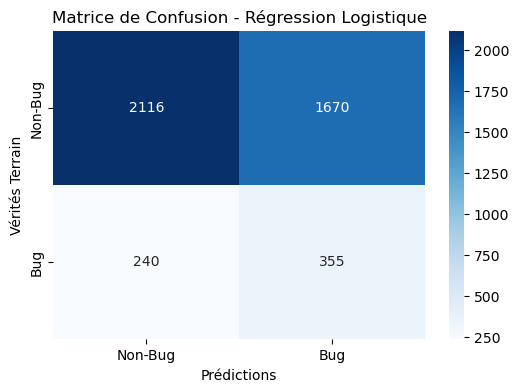

In [17]:
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print('Matrice de confusion - Régression Logistique :')
print(conf_matrix_log_reg)
plot_confusion_matrix(conf_matrix_log_reg, 'Matrice de Confusion - Régression Logistique')

Random Forest:

Matrice de confusion - Random Forest :
[[3584  202]
 [ 443  152]]


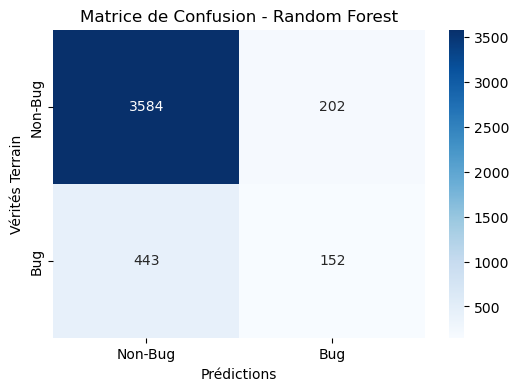

In [18]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print('Matrice de confusion - Random Forest :')
print(conf_matrix_rf)
plot_confusion_matrix(conf_matrix_rf, 'Matrice de Confusion - Random Forest')


On peut produire des rapports de classification pour chacun des entraînements. Pour la régression linéaire:

In [19]:
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.90      0.56      0.69      3786
           1       0.18      0.60      0.27       595

    accuracy                           0.56      4381
   macro avg       0.54      0.58      0.48      4381
weighted avg       0.80      0.56      0.63      4381



Pour random forest:

In [20]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3786
           1       0.43      0.26      0.32       595

    accuracy                           0.85      4381
   macro avg       0.66      0.60      0.62      4381
weighted avg       0.83      0.85      0.84      4381



On peut comparer, visuellement les performances, des modèles. Pour la régression linéraire

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve

In [22]:
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
print(f'ROC-AUC Score - Régression Logistique : {roc_auc_log_reg:.4f}')
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log_reg)

ROC-AUC Score - Régression Logistique : 0.6128


Pour random forest:

In [23]:
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f'ROC-AUC Score - Random Forest : {roc_auc_rf:.4f}')
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

ROC-AUC Score - Random Forest : 0.7414


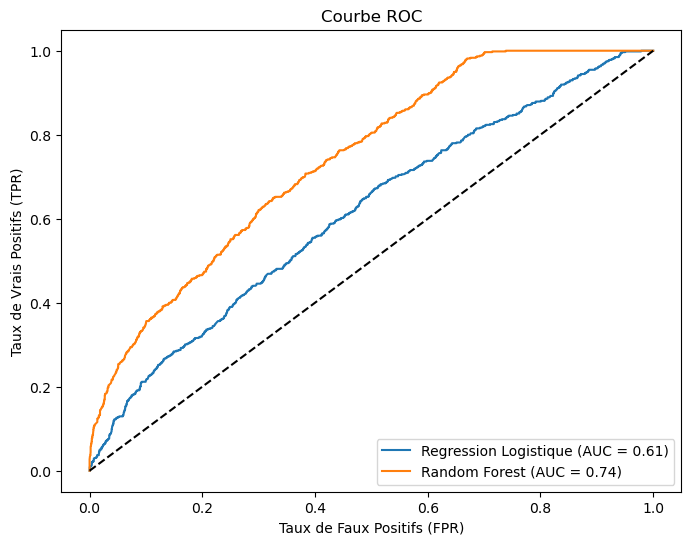

In [24]:
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Regression Logistique (AUC = {roc_auc_log_reg:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()
